In [1]:
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from jupyfun import progressbar

%matplotlib inline
auto_plot_style()

In [2]:
path        = Path("/home/gonzalo/data/COLINA/mc/colina/survival_20260305_164629/")
filenames   = sorted(path.glob("*.h5"))
r_el        = 32
zmax        = 240
form_factor = 1
rmax        = zmax * form_factor + r_el
aspect      = rmax/zmax
zcut        = 0.05 # mm
rcut        = 5.00 # mm

len(filenames)

100

In [66]:
filename = filenames[3]
df = pd.read_hdf(filename, "/endpoints")
#df = pd.concat([pd.read_hdf(filename, "/endpoints") for filename in filenames], ignore_index=True)
df.insert(df.shape[1], "r0", (df.x0**2 + df.y0**2)**0.5)
df.insert(df.shape[1], "r1", (df.x1**2 + df.y1**2)**0.5)
df

,event,x0,y0,z0,x1,y1,z1,t,r0,r1
0,0,19.724520,160.929489,203.047379,1.518871,17.966549,-0.028455,148.289993,162.133759,18.030636
1,1,10.447427,88.409416,159.119705,1.808208,14.074517,-0.023077,91.790001,89.024567,14.190196
2,2,96.644470,-100.739243,205.490952,11.294549,-12.058867,-0.024506,138.690002,139.601379,16.522202
3,3,94.295586,-117.807350,236.190475,10.551495,-12.757680,-0.014633,170.080002,150.898071,16.555737
4,4,-27.471735,44.676704,183.671234,-4.167946,6.747416,-0.004896,98.959999,52.447155,7.930914
...,...,...,...,...,...,...,...,...,...,...
999995,999995,-180.838150,126.859840,239.589874,-16.130232,10.706881,-0.008925,301.500000,220.897842,19.360312
999996,999996,168.391739,38.965298,149.530457,20.614609,4.443118,-0.027130,120.070000,172.841171,21.087992
999997,999997,-122.588280,-97.662727,161.785934,-15.284507,-12.264046,-0.031368,118.610001,156.735107,19.596504
999998,999998,22.090630,99.681625,150.551712,3.237760,15.871159,-0.024407,89.970001,102.100060,16.198048


In [4]:
df.describe()

,event,x0,y0,z0,x1,y1,z1,t,r0,r1
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,499999.500000,0.054698,0.032589,172.264969,0.020894,-0.026531,2.509870,139.770004,136.098221,19.588345
std,288675.278932,105.241432,105.424644,52.184063,20.138838,20.218130,18.294495,99.132042,60.636318,20.743389
min,0.000000,-271.415863,-271.359650,0.004937,-271.430634,-271.350189,-0.044730,0.020000,0.232337,0.014443
25%,249999.750000,-76.805660,-77.060690,139.501057,-11.055364,-11.077416,-0.021255,86.470001,88.982996,14.895853
50%,499999.500000,0.064463,0.004193,183.926888,0.007154,0.001918,-0.013873,124.360001,135.999382,18.292327
75%,749999.250000,76.978289,77.156254,215.218414,11.038979,11.084443,-0.006553,164.330002,183.154598,19.551956
max,999999.000000,270.045135,270.344788,239.999969,270.020233,270.388123,240.044800,2252.750000,271.884399,271.904358


In [38]:
def compute_survival(df, zcut, rcut):
    reached_gate = (df.z1 > -zcut) & (df.r1 < (r_el-rcut))
    return pd.Series(dict( nevt  = len(df)
                         , ngate = np.count_nonzero(reached_gate)
                         , dt    = df.t[reached_gate].mean()
                         ))

In [39]:
nbinsr = 100
nbinsz = 100
rbins = np.linspace(0, rmax, nbinsr+1)
zbins = np.linspace(0, zmax, nbinsz+1)
bin_width_r = np.diff(rbins)[0]
bin_width_z = np.diff(zbins)[0]

indices = np.meshgrid( np.arange(nbinsr)
                     , np.arange(nbinsz)
                     , indexing="ij")
indices = np.array(list(zip(*map(np.ravel, indices)))).T
empty_survival_map = pd.DataFrame(dict(rbin=indices[0], zbin=indices[1], nevt=0, ngate=0, dt=0))
empty_survival_map

,rbin,zbin,nevt,ngate,dt
0,0,0,0,0,0
1,0,1,0,0,0
2,0,2,0,0,0
3,0,3,0,0,0
4,0,4,0,0,0
...,...,...,...,...,...
9995,99,95,0,0,0
9996,99,96,0,0,0
9997,99,97,0,0,0
9998,99,98,0,0,0


In [40]:
dfs = []
for filename in progressbar(filenames):
    df = pd.read_hdf(filename, "/endpoints")
    df.insert(df.shape[1], "r0", (df.x0**2 + df.y0**2)**0.5)
    df.insert(df.shape[1], "r1", (df.x1**2 + df.y1**2)**0.5)

    df = ( df.assign( rbin = lambda df: np.clip(np.digitize(df.r0, rbins)-1, 0, nbinsr-1)
                    , zbin = lambda df: np.clip(np.digitize(df.z0, zbins)-1, 0, nbinsz-1))
             .groupby("rbin zbin".split())
             .apply(compute_survival, zcut, rcut, include_groups=False)
             .reset_index()
         )
    dfs.append(df)

dfs = pd.concat(dfs + [empty_survival_map], ignore_index=True)
dfs = dfs.groupby("rbin zbin".split()).agg(dict(nevt="sum", ngate="sum", dt="mean")).reset_index()
dfs.insert(dfs.shape[1], "r"     , (dfs.rbin + 0.5) * bin_width_r)
dfs.insert(dfs.shape[1], "z"     , (dfs.zbin + 0.5) * bin_width_z)
dfs.insert(dfs.shape[1], "out"   , (dfs.r - r_el) / dfs.z > 1)
dfs.insert(dfs.shape[1], "prob"  , dfs.ngate / np.clip(dfs.nevt, 1, None))
dfs.insert(dfs.shape[1], "binvol", 2 * np.pi * dfs.r * bin_width_r * bin_width_z)
dfs.insert(dfs.shape[1], "effvol", dfs.binvol * dfs.prob)

survival = dfs

Item 100 of 100 | 1.38 s/item | ETA 0.0 min | Ellapsed 2.3 min


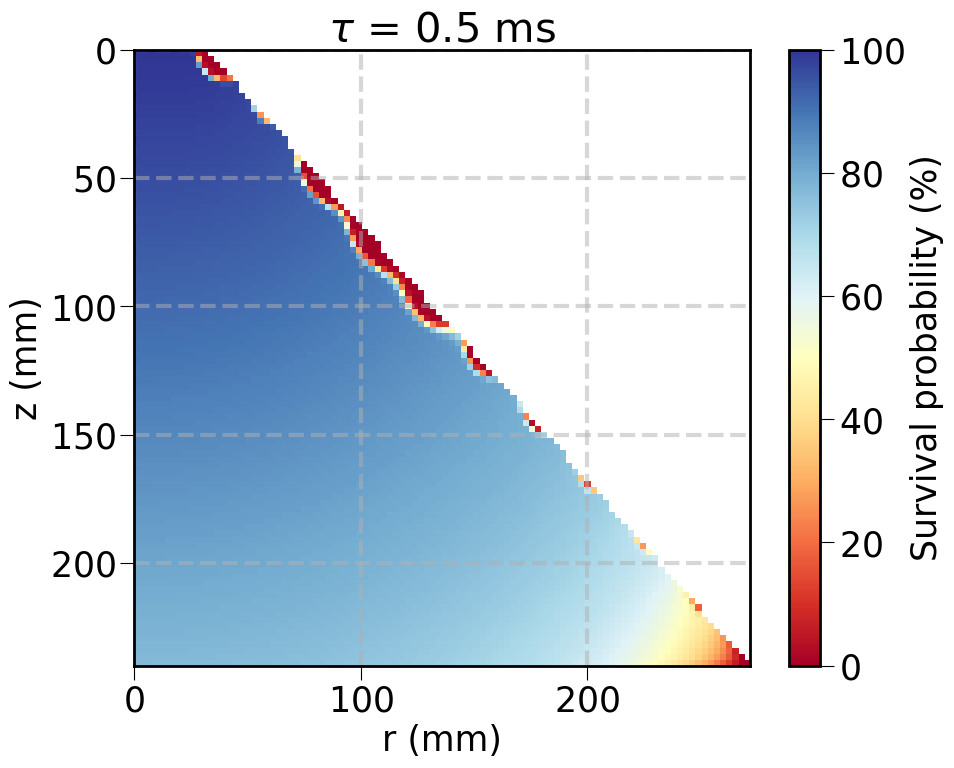

In [88]:
lifetime = 500

sp  = survival.prob.values.copy()
sp *= np.exp(-survival.dt/lifetime)
sp  = np.where(survival.out, np.nan, sp)
sp  = sp.reshape(nbinsr, nbinsz)
sp  = sp * 100

extent = (rbins.min(), rbins.max(), zbins.min(), zbins.max())

plt.imshow(sp.T, origin="lower", extent=extent, aspect=aspect, vmin=0, vmax=100, cmap="RdYlBu")
plt.gca().invert_yaxis()
plt.colorbar().set_label("Survival probability (%)")
plt.xlabel("r (mm)")
plt.ylabel("z (mm)")
plt.title(f"$\\tau$ = {lifetime/1e3} ms")
plt.grid()

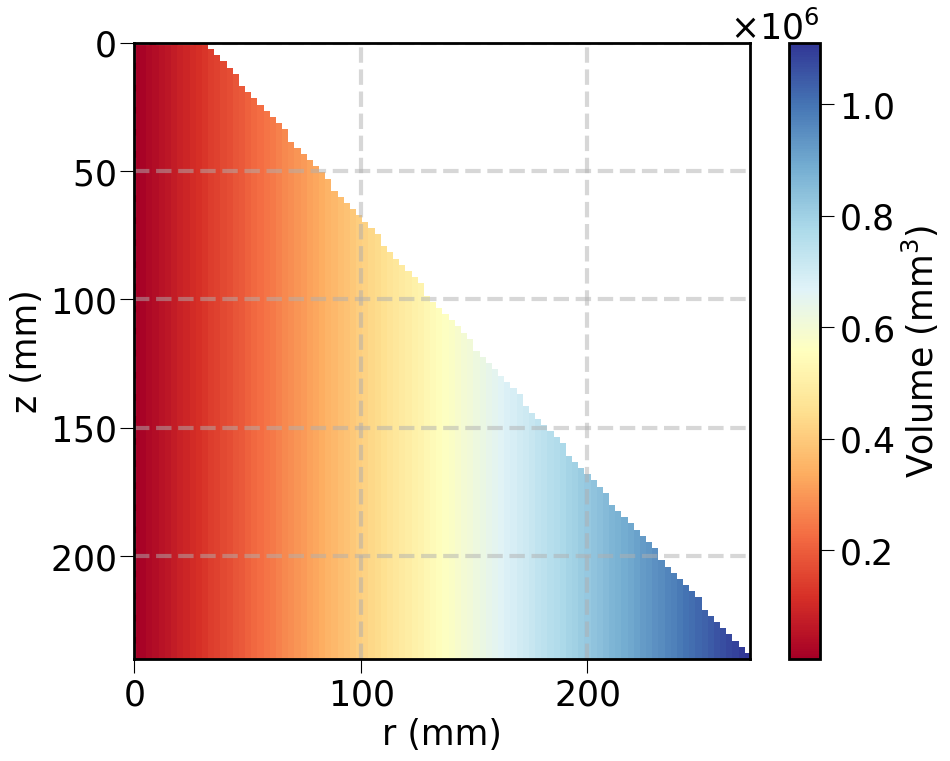

In [89]:
sp  = np.where(survival.out, np.nan, survival.binvol.values)
sp  = sp.reshape(nbinsr, nbinsz)
sp  = sp * 100

extent = (rbins.min(), rbins.max(), zbins.min(), zbins.max())

plt.imshow(sp.T, origin="lower", extent=extent, aspect=aspect, cmap="RdYlBu")
plt.gca().invert_yaxis()
plt.colorbar().set_label("Volume (mm$^3$)")
plt.xlabel("r (mm)")
plt.ylabel("z (mm)")
plt.grid()

In [90]:
total_vol = survival[~survival.out.values].binvol.sum()/1e6
total_vol

21.035794033157416

In [91]:
total_vol_analytical = np.pi/3/form_factor*(rmax**3-r_el**3)/1e6
total_vol_analytical

21.039120337384702

In [92]:
df = survival
df = df[~df.out.values]
eff_vol = (df.effvol * np.exp(-df.dt/lifetime)).sum()/1e6
#eff_vol = survival[~survival.out.values].effvol.sum()/1e6
eff_vol, eff_vol/total_vol*100

(15.660714750614646, 74.4479372916926)

0.10517927227786564


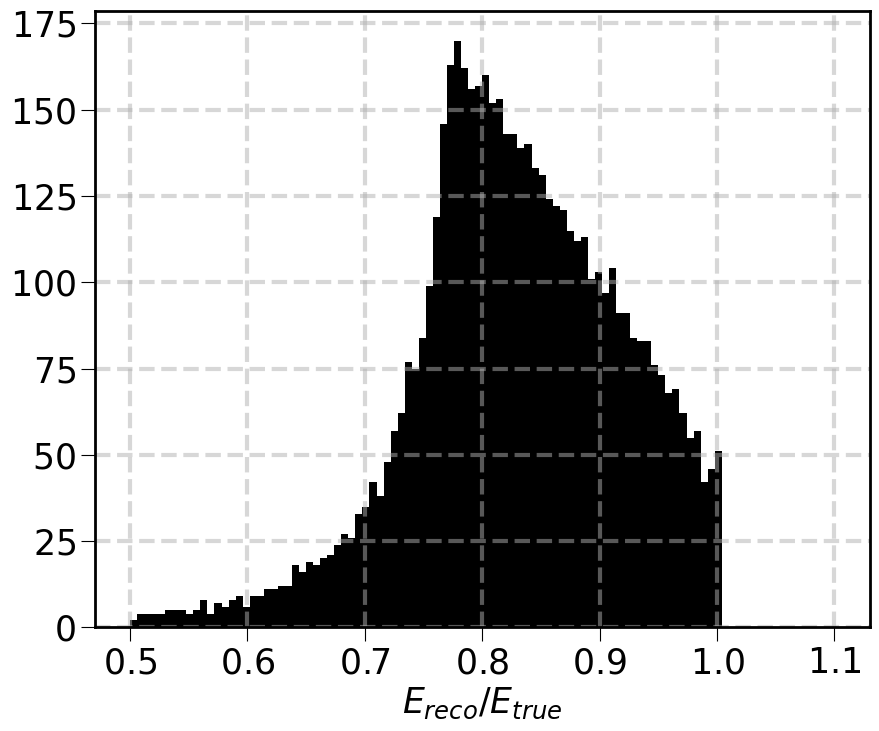

In [93]:
df = survival
df = df[~df.out.values]
e = np.exp(-df.dt/lifetime)
plt.hist(e, np.linspace(0.5, 1.1, 101))
print(e.std())
plt.xlabel("$E_{reco}/E_{true}$")
plt.grid()

In [99]:
survival.iloc[0].name

0